# ***🌿 ArvyaX Machine Learning Internship Assignment***

#### **Theme: From Understanding Humans → To Guiding Them**

*At ArvyaX, we are building AI systems that go beyond prediction.*

[ML Assignment](https://www.introtoartificialintelligence.com/CodeShop/ml-assignment)

## **Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np


## **Loading, Reading and Checking top 7 rows**

In [ ]:
df_train = pd.read_csv('arvyax_reflective_dataset.csv')


df_train.head(7)

,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity
0,1,The ocean ambience helped me stop drifting and...,ocean,12,6.5,4,2,afternoon,mixed,calm_face,clear,focused,3
1,2,"I tried to relax during the forest ambience, y...",forest,35,6.0,2,4,evening,calm,tired_face,vague,restless,3
2,3,The forest session slowed my thoughts and I fe...,forest,3,NaN,2,1,night,overwhelmed,happy_face,clear,calm,3
3,4,"the mountain ambience was pleasant, though i c...",mountain,25,7.0,4,4,night,focused,calm_face,vague,neutral,1
4,5,"The rain session gave me a pause, but the pres...",rain,25,5.0,3,5,afternoon,NaN,tense_face,clear,overwhelmed,5
5,6,after the forest track i feel peaceful and les...,forest,12,8.0,3,2,morning,mixed,calm_face,vague,calm,3
6,7,Nothing strong came up during the rain session...,rain,20,6.5,2,4,early_morning,calm,neutral_face,conflicted,neutral,1


## **Checking each feature datatypes**

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1200 non-null   int64  
 1   journal_text        1200 non-null   object 
 2   ambience_type       1200 non-null   object 
 3   duration_min        1200 non-null   int64  
 4   sleep_hours         1193 non-null   float64
 5   energy_level        1200 non-null   int64  
 6   stress_level        1200 non-null   int64  
 7   time_of_day         1200 non-null   object 
 8   previous_day_mood   1185 non-null   object 
 9   face_emotion_hint   1077 non-null   object 
 10  reflection_quality  1200 non-null   object 
 11  emotional_state     1200 non-null   object 
 12  intensity           1200 non-null   int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 122.0+ KB


Note - *From above we observe that "sleep_hours", "previous_day_mood" and "face_emotion_hint" these features have missing values*

## **Checking missing values**

In [ ]:
df_train.isna().sum()

,0
id,0
journal_text,0
ambience_type,0
duration_min,0
sleep_hours,7
energy_level,0
stress_level,0
time_of_day,0
previous_day_mood,15
face_emotion_hint,123


## **Checking duplicates**

In [ ]:
df_train.duplicated().sum()

np.int64(0)

In [ ]:
#df_train.dropna(inplace=True)

In [ ]:
df_train['sleep_hours'].median()

6.0

### **Handling missing values**

In [ ]:
df_train['sleep_hours'] = df_train['sleep_hours'].fillna(df_train['sleep_hours'].median())

In [ ]:
df_train['previous_day_mood'] = df_train['previous_day_mood'].fillna("unknown")

In [ ]:
df_train['face_emotion_hint'] = df_train['face_emotion_hint'].fillna("missing")

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1200 non-null   int64  
 1   journal_text        1200 non-null   object 
 2   ambience_type       1200 non-null   object 
 3   duration_min        1200 non-null   int64  
 4   sleep_hours         1200 non-null   float64
 5   energy_level        1200 non-null   int64  
 6   stress_level        1200 non-null   int64  
 7   time_of_day         1200 non-null   object 
 8   previous_day_mood   1200 non-null   object 
 9   face_emotion_hint   1200 non-null   object 
 10  reflection_quality  1200 non-null   object 
 11  emotional_state     1200 non-null   object 
 12  intensity           1200 non-null   int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 122.0+ KB


In [ ]:
df_train['reflection_quality'].value_counts()

,count
reflection_quality,
clear,411
vague,400
conflicted,389


In [ ]:
df_train['reflection_quality'] = df_train['reflection_quality'].map({
    "clear": 1,
    "vague": 2,
    "conflicted": 3

})

In [ ]:
df_train['time_of_day'].value_counts()

,count
time_of_day,
afternoon,319
morning,302
night,286
evening,268
early_morning,25


In [ ]:
df_train['time_of_day'] = df_train['time_of_day'].map({
    "afternoon": 1,
    "morning": 2,
    "night": 3,
    "evening": 4,
    "early_morning": 5

})

In [ ]:
df_train['previous_day_mood'].value_counts()

,count
previous_day_mood,
mixed,213
restless,208
neutral,203
overwhelmed,202
calm,182
focused,177
unknown,15


In [ ]:
df_train['previous_day_mood'] = df_train['previous_day_mood'].map({
    "mixed": 2,
    "restless": 3,
    "neutral": 4,
    "overwhelmed": 1,
    "calm": 6,
    "focused": 5,
    "unknown": 7

})

In [ ]:
df_train['face_emotion_hint'].value_counts()

,count
face_emotion_hint,
neutral_face,214
calm_face,197
none,174
happy_face,173
tense_face,164
tired_face,155
missing,123


In [ ]:
df_train['face_emotion_hint'] = df_train['face_emotion_hint'].map({
    "neutral_face": 1,
    "calm_face": 2,
    "none": 3,
    "happy_face": 4,
    "tense_face": 5,
    "tired_face": 6,
    "missing": 7

})

In [ ]:
df_train['emotional_state'].value_counts()

,count
emotional_state,
calm,216
restless,209
neutral,201
focused,193
mixed,191
overwhelmed,190


In [ ]:
df_train['emotional_state'] = df_train['emotional_state'].map({
    "calm": 0,
    "restless": 1,
    "neutral": 2,
    "focused": 3,
    "mixed": 4,
    "overwhelmed": 5
})

In [ ]:
df_train['ambience_type'].value_counts()

,count
ambience_type,
ocean,268
mountain,252
forest,231
cafe,229
rain,220


In [ ]:
df_train['ambience_type'] = df_train['ambience_type'].map({
    "ocean": 1,
    "mountain": 2,
    "forest": 3,
    "cafe": 4,
    "rain": 5
})

In [ ]:
df_train.columns

Index(['id', 'journal_text', 'ambience_type', 'duration_min', 'sleep_hours',
       'energy_level', 'stress_level', 'time_of_day', 'previous_day_mood',
       'face_emotion_hint', 'reflection_quality', 'emotional_state',
       'intensity'],
      dtype='object')

### **text-only model for "emotional_state"**

In [ ]:

from sklearn.model_selection import train_test_split

# ==============================
# 3. DEFINE FEATURES & TARGET
# ==============================
X_es_text = df_train['journal_text']
y_es_text = df_train['emotional_state']

# ==============================
# 4. TRAIN-TEST SPLIT
# ==============================
X_train_est, X_test_est, y_train_est, y_test_est = train_test_split(
    X_es_text, y_es_text, test_size=0.11, random_state=42
)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_text = TfidfVectorizer(
    max_features=800,
    ngram_range=(1,2),
    stop_words='english'
)



X_train_tfidf_est = tfidf_text.fit_transform(X_train_est)
X_test_tfidf_est = tfidf_text.transform(X_test_est)


# ==============================
# 6. TRAIN SVM MODEL
# ==============================
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

es_text_model = LinearSVC(
    C=1,
    class_weight='balanced',
    max_iter=8000
)

es_text_model.fit(X_train_tfidf_est, y_train_est)

# ==============================
# 7. PREDICTION
# ==============================
es_text_preds = es_text_model.predict(X_test_tfidf_est)

# ==============================
# 8. EVALUATION
# ==============================
print('------' * 10)
print("Text-Only (Emotional State) :- SVM Accuracy:", accuracy_score(y_test_est, es_text_preds))
print(classification_report(y_test_est, es_text_preds))

------------------------------------------------------------
Text-Only (Emotional State) :- SVM Accuracy: 0.7575757575757576
              precision    recall  f1-score   support

           0       0.69      0.69      0.69        26
           1       0.72      0.93      0.81        14
           2       0.89      0.62      0.73        26
           3       0.70      0.88      0.78        24
           4       0.79      0.65      0.71        23
           5       0.81      0.89      0.85        19

    accuracy                           0.76       132
   macro avg       0.77      0.78      0.76       132
weighted avg       0.77      0.76      0.75       132



### **text-only model for "intensity"**

In [ ]:

from sklearn.ensemble import RandomForestClassifier


# ==============================
# 2. DEFINE FEATURES & TARGET
# ==============================
X_int = df_train['journal_text']
y_int = df_train['intensity']

# ==============================
# 3. TRAIN-TEST SPLIT
# ==============================
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_int, y_int, test_size=0.11, random_state=42
)

# ==============================
# 4. TF-IDF VECTORIZATION
# ==============================
tfidf_int = TfidfVectorizer(
    max_features=800,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_tfidf_int = tfidf_int.fit_transform(X_train_new)
X_test_tfidf_int = tfidf_int.transform(X_test_new)

# ==============================
# 5. TRAIN RANDOM FOREST
# ==============================
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf_int, y_train_new)

# ==============================
# 6. PREDICTION
# ==============================
preds_int = rf_model.predict(X_test_tfidf_int)

# ==============================
# 7. EVALUATION
# ==============================
print('------' * 10)
print("Text-Only (Intensity) :- Random Forest Accuracy:", accuracy_score(y_test_new, preds_int))
print(classification_report(y_test_new, preds_int))

------------------------------------------------------------
Text-Only (Intensity) :- Random Forest Accuracy: 0.25
              precision    recall  f1-score   support

           1       0.33      0.19      0.24        21
           2       0.27      0.16      0.20        25
           3       0.46      0.21      0.29        28
           4       0.21      0.53      0.30        32
           5       0.17      0.08      0.11        26

    accuracy                           0.25       132
   macro avg       0.29      0.23      0.23       132
weighted avg       0.29      0.25      0.23       132



## **Feature Engineering**

*(Let's see does adding more feature will help us for strong modeling impactful results ..!)*

In [ ]:
from textblob import TextBlob

df_train['sentiment'] = df_train['journal_text'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [ ]:
df_train['text_length'] = df_train['journal_text'].apply(len)
df_train['word_count'] = df_train['journal_text'].apply(lambda x: len(x.split()))

In [ ]:
df_train['stress_energy_ratio'] = df_train['stress_level'] / (df_train['energy_level'] + 1)

In [ ]:
df_train['emotional_signal'] = df_train['sentiment'] * df_train['word_count']

In [ ]:
df_train['sleep_deficit'] = 7 - df_train['sleep_hours']

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1200 non-null   int64  
 1   journal_text         1200 non-null   object 
 2   ambience_type        1200 non-null   int64  
 3   duration_min         1200 non-null   int64  
 4   sleep_hours          1200 non-null   float64
 5   energy_level         1200 non-null   int64  
 6   stress_level         1200 non-null   int64  
 7   time_of_day          1200 non-null   int64  
 8   previous_day_mood    1200 non-null   int64  
 9   face_emotion_hint    1200 non-null   int64  
 10  reflection_quality   1200 non-null   int64  
 11  emotional_state      1200 non-null   int64  
 12  intensity            1200 non-null   int64  
 13  sentiment            1200 non-null   float64
 14  text_length          1200 non-null   int64  
 15  word_count           1200 non-null   i

In [ ]:
df_train.columns

Index(['id', 'journal_text', 'ambience_type', 'duration_min', 'sleep_hours',
       'energy_level', 'stress_level', 'time_of_day', 'previous_day_mood',
       'face_emotion_hint', 'reflection_quality', 'emotional_state',
       'intensity', 'sentiment', 'text_length', 'word_count',
       'stress_energy_ratio', 'emotional_signal', 'sleep_deficit'],
      dtype='object')

In [ ]:
df_train = df_train[['id', 'journal_text', 'ambience_type', 'duration_min', 'sleep_hours',
       'energy_level', 'stress_level', 'time_of_day', 'previous_day_mood',
       'face_emotion_hint', 'reflection_quality','sentiment', 'text_length', 'word_count',
       'stress_energy_ratio', 'emotional_signal', 'sleep_deficit','emotional_state',
       'intensity']]

### **Heatmap for Emotional State**

In [ ]:
corr_features = [
    'id',
    'ambience_type',
    'duration_min',
    'sleep_hours',
    'energy_level',
    'stress_level',
    'time_of_day',
    'previous_day_mood',
    'face_emotion_hint',
    'reflection_quality',
    'text_length',
    'word_count',
    'sentiment',
    'stress_energy_ratio',
    'emotional_signal',
    'sleep_deficit',
    'emotional_state'

]

import plotly.express as px
import plotly.graph_objects as go

# Calculate correlation matrix again
corr_matrix = df_train[corr_features].corr()

# Select only correlations with target column
target_corr = corr_matrix[['emotional_state']].drop(index='emotional_state').reset_index()
target_corr.columns = ['Feature', 'Correlation']
target_corr['AbsCorrelation'] = target_corr['Correlation'].abs()

# Sort by absolute correlation
target_corr = target_corr.sort_values(by='AbsCorrelation', ascending=False)

fig = px.bar(
    target_corr,
    x='Feature',
    y='Correlation',
    color='Correlation',
    title='Feature Correlations : Emotional State',
    color_continuous_scale='earth',
    text=target_corr['Correlation'].round(3)
)

fig.update_layout(
    width=900,
    height=650,
    xaxis_title='Feature',
    yaxis_title='Correlation with Emotional State',
    bargap=0.3
)

fig.update_traces(
    textposition='outside'
)

fig.show()

Note - *From above plot we observe that features like - previous_day_mood, ambience_type, reflection_quality and duration_min are least impactful.*

### **Time for :- Text-Only + Metadata (Emotional State) model**

In [ ]:
# ✅ Example
selected_features_es = [
    'text_length',
    'word_count',
    'face_emotion_hint',
    'sleep_deficit',
    'sleep_hours',
    'emotional_signal',
    'time_of_day',
    'stress_level',
    'sentiment',
    'id',
    'energy_level',
    'stress_energy_ratio'

]

# Create a new DataFrame for X (features)
X_meta = df_train[selected_features_es]

# Target variable
y_emotional_state = df_train['emotional_state']



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_es = TfidfVectorizer(
    max_features=800,
    ngram_range=(1,2),
    stop_words='english'
)

X_text_es = tfidf_es.fit_transform(df_train['journal_text'])

In [ ]:
from scipy.sparse import hstack

X_emotional_state = hstack([X_text_es, X_meta])
y_emotional_state = df_train['emotional_state']

In [ ]:
X_train_es, X_test_es, y_emotional_state_train, y_emotional_state_test = train_test_split(
    X_emotional_state, y_emotional_state, test_size=0.11, random_state=42
)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV


# ==============================
# 1. BASE MODEL
# ==============================
base_svm = LinearSVC(C=1, max_iter=800)

# ==============================
# 2. CALIBRATION WRAPPER
# ==============================
emotional_state_model = CalibratedClassifierCV(
    base_svm,
    method='sigmoid',   # or 'isotonic' (slower)
    cv=5
)

# ==============================
# 3. TRAIN
# ==============================
emotional_state_model.fit(X_train_es, y_emotional_state_train)

# ==============================
# 4. PREDICT
# ==============================
emotional_state_preds = emotional_state_model.predict(X_test_es)

print('------' * 12)
print("Text-Only + Metadata (Emotional State) :- SVM (Calibrated) Accuracy:", accuracy_score(y_emotional_state_test, emotional_state_preds))
print(classification_report(y_emotional_state_test, emotional_state_preds))

------------------------------------------------------------------------
Text-Only + Metadata (Emotional State) :- SVM (Calibrated) Accuracy: 0.7727272727272727
              precision    recall  f1-score   support

           0       0.70      0.73      0.72        26
           1       0.76      0.93      0.84        14
           2       0.90      0.69      0.78        26
           3       0.68      0.96      0.79        24
           4       0.88      0.61      0.72        23
           5       0.83      0.79      0.81        19

    accuracy                           0.77       132
   macro avg       0.79      0.78      0.78       132
weighted avg       0.79      0.77      0.77       132



Note - ***From above model results we observe that - Text + Metadata and Feature Engineering give us 1% increase in our model accuracy (improved) as compare to "Text-Only" model accuracy***

### **Part 5 — Feature Understanding (Emotional State)**


===== TOP SVM FEATURES =====


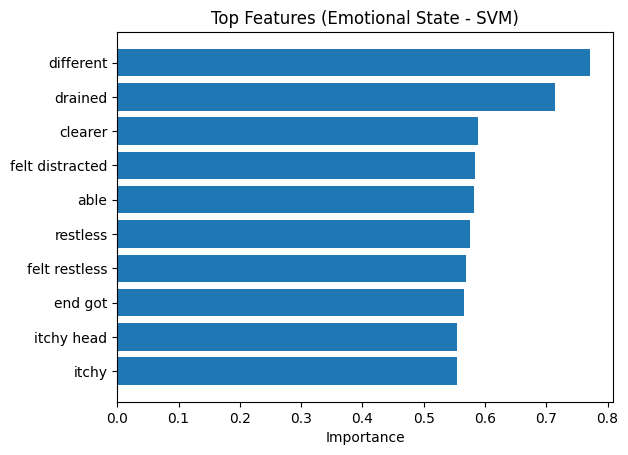

In [ ]:
svm_base = emotional_state_model.calibrated_classifiers_[0].estimator

coef = svm_base.coef_

# For multi-class → average importance
importance = np.mean(np.abs(coef), axis=0)

tfidf_features_new = tfidf_es.get_feature_names_out()

# Corrected: Combine TF-IDF feature names with metadata feature names
all_features = list(tfidf_features_new) + selected_features_es


svm_feature_df = pd.DataFrame({
    "feature": all_features,
    "importance": importance
})

# Sort
svm_feature_df = svm_feature_df.sort_values(
    by="importance", ascending=False
)

print("\n===== TOP SVM FEATURES =====")

import matplotlib.pyplot as plt

top_features = svm_feature_df.head(10)

plt.figure()
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Features (Emotional State - SVM)")
plt.xlabel("Importance")
plt.show()



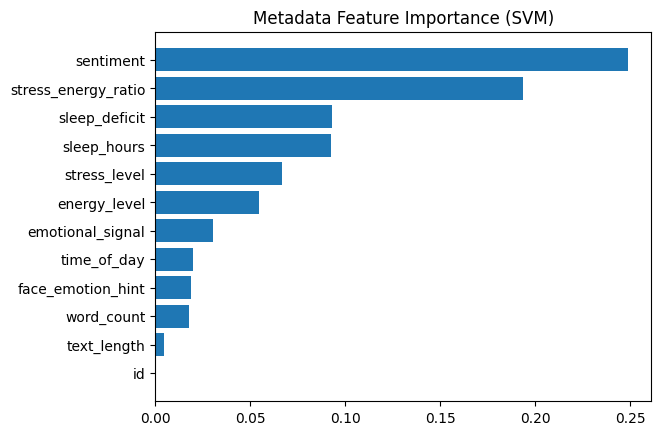

In [ ]:
import matplotlib.pyplot as plt

meta_df = svm_feature_df[
    svm_feature_df['feature'].isin(selected_features_es)
]

plt.figure()
plt.barh(meta_df['feature'], meta_df['importance'])
plt.gca().invert_yaxis()
plt.title("Metadata Feature Importance (SVM)")
plt.show()

### **Part 4 — Uncertainty Modeling (Emotional State)**

In [ ]:
# ==============================
# GET PROBABILITIES
# ==============================
probs_es = emotional_state_model.predict_proba(X_test_es)

# Confidence = max probability per row
confidence_scores_es = probs_es.max(axis=1)

# ==============================
# DEFINE UNCERTAINTY THRESHOLD
# ==============================
threshold_es = np.percentile(confidence_scores_es, 25)

uncertain_flag_es = (confidence_scores_es < threshold_es).astype(int)

# ==============================
# CREATE RESULT DATAFRAME
# ==============================


uncertainty_df_es = pd.DataFrame({
    "true_emotional_state": y_emotional_state_test.values,
    "predicted_emotional_state": emotional_state_preds,
    "confidence_emotional_state": confidence_scores_es,
    "uncertain_flag_emotional_state": uncertain_flag_es
})

print("\n===== UNCERTAINTY OUTPUT ====================")
print(uncertainty_df_es.head(11))


===== UNCERTAINTY OUTPUT ====================
    true_emotional_state  predicted_emotional_state  \
0                      2                          2   
1                      5                          5   
2                      0                          0   
3                      1                          1   
4                      3                          3   
5                      3                          3   
6                      0                          0   
7                      0                          0   
8                      4                          4   
9                      0                          0   
10                     0                          0   

    confidence_emotional_state  uncertain_flag_emotional_state  
0                     0.695190                               0  
1                     0.768926                               0  
2                     0.804439                               0  
3                     0.813538  

### **Heatmap for Intensity**

In [ ]:
corr_features_new = [
    'id',
    'ambience_type',
    'duration_min',
    'sleep_hours',
    'energy_level',
    'stress_level',
    'time_of_day',
    'previous_day_mood',
    'face_emotion_hint',
    'reflection_quality',
    'text_length',
    'word_count',
    'sentiment',
    'stress_energy_ratio',
    'emotional_signal',
    'sleep_deficit',
    'intensity'

]

import plotly.express as px
import plotly.graph_objects as go

# Calculate correlation matrix again
corr_matrix_new = df_train[corr_features_new].corr()

# Select only correlations with target column
target_corr_new = corr_matrix_new[['intensity']].drop(index='intensity').reset_index()
target_corr_new.columns = ['Feature', 'Correlation']
target_corr_new['AbsCorrelation'] = target_corr_new['Correlation'].abs()

# Sort by absolute correlation
target_corr_new = target_corr_new.sort_values(by='AbsCorrelation', ascending=False)

fig = px.bar(
    target_corr_new,
    x='Feature',
    y='Correlation',
    color='Correlation',
    title='Feature Correlations : Intensity',
    color_continuous_scale='earth',
    text=target_corr_new['Correlation'].round(3)
)

fig.update_layout(
    width=900,
    height=650,
    xaxis_title='Feature',
    yaxis_title='Correlation with Intensity',
    bargap=0.3
)

fig.update_traces(
    textposition='outside'
)

fig.show()

Note - *From above plot we observe that features like - energy_level, previous_day_mood, stress_level, stress_energy_ratio and ambience_type are least impactful, basically one feature engineering column not so impactful*

### **Time for :- Text-Only + Metadata (Intensity) model**

In [ ]:
# ✅ Example
selected_features_int = [
    'time_of_day',
    'text_length',
    'reflection_quality',
    'word_count',
    'emotional_signal',
    'sleep_hours',
    'sleep_deficit',
    'sentiment',
    'face_emotion_hint',
    'id',
    'duration_min'

]

# Create a new DataFrame for X (features)
X_int = df_train[selected_features_int]

# Target variable
y_intensity = df_train['intensity']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_int = TfidfVectorizer(
    max_features=800,
    ngram_range=(1,2),
    stop_words='english'
)

X_text_int = tfidf_int.fit_transform(df_train['journal_text'])

In [ ]:
from scipy.sparse import hstack

X_intensity = hstack([X_text_int, X_int])
y_intensity = df_train['intensity']

In [ ]:
X_train_int, X_test_int, y_intensity_train, y_intensity_test = train_test_split(
    X_intensity, y_intensity, test_size=0.11, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

intensity_model = RandomForestClassifier(
    n_estimators=800,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

intensity_model.fit(X_train_int, y_intensity_train)

intensity_preds = intensity_model.predict(X_test_int)

print('------' * 12)
print("Text-Only + Metadata (Intensity) :- Random Forest Accuracy:", accuracy_score(y_intensity_test, intensity_preds))
print(classification_report(y_intensity_test, intensity_preds))

------------------------------------------------------------------------
Text-Only + Metadata (Intensity) :- Random Forest Accuracy: 0.2803030303030303
              precision    recall  f1-score   support

           1       0.32      0.33      0.33        21
           2       0.27      0.28      0.27        25
           3       0.40      0.36      0.38        28
           4       0.27      0.19      0.22        32
           5       0.19      0.27      0.22        26

    accuracy                           0.28       132
   macro avg       0.29      0.29      0.28       132
weighted avg       0.29      0.28      0.28       132



Note - ***From above model results we observe that - Text + Metadata and Feature Engineering give us 3% increase in our model accuracy (improved) as compare to "Text-Only" model accuracy***

### **Part 5 — Feature Understanding (Intensity)**

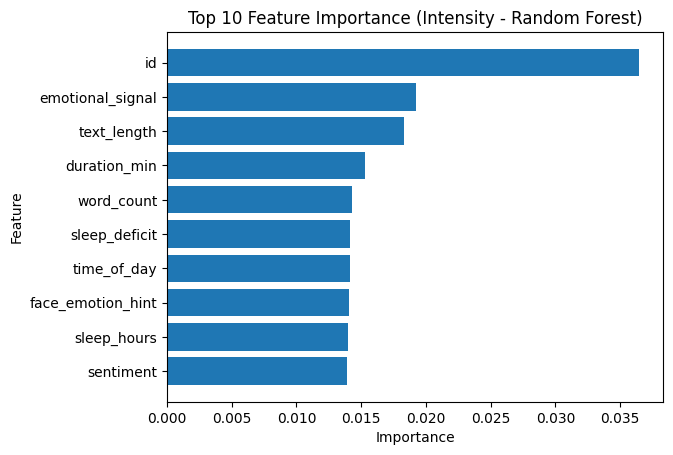

In [ ]:


# Feature names (VERY IMPORTANT — must match training data)
# Get feature names from TF-IDF vectorizer
tfidf_feature_names = tfidf_int.get_feature_names_out()

# Get feature names from the metadata features
meta_feature_names = selected_features_int

# Combine all feature names
feature_names = np.concatenate([tfidf_feature_names, meta_feature_names])


# Get importance
importances = intensity_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort
feature_importance_df = feature_importance_df.sort_values(
    by="importance", ascending=False
)

import matplotlib.pyplot as plt

# Top 10 features
top_features = feature_importance_df.head(10)

plt.figure()
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()   # highest on top
plt.title("Top 10 Feature Importance (Intensity - Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### **Part 4 — Uncertainty Modeling (Intensity)**

In [ ]:
# ==============================
# GET PROBABILITIES
# ==============================
probs_int = intensity_model.predict_proba(X_test_int)

# Confidence = max probability per row
confidence_scores_int = probs_int.max(axis=1)

# ==============================
# DEFINE UNCERTAINTY THRESHOLD
# ==============================
threshold = np.percentile(confidence_scores_int, 25)

uncertain_flag_int = (confidence_scores_int < threshold).astype(int)

# ==============================
# CREATE RESULT DATAFRAME
# ==============================


uncertainty_df_int = pd.DataFrame({
    "true_intensity": y_intensity_test.values,
    "predicted_intensity": intensity_preds,
    "confidence_intensity": confidence_scores_int,
    "uncertain_flag_intensity": uncertain_flag_int
})

print("\n===== UNCERTAINTY OUTPUT ====================")
print(uncertainty_df_int.head(11))


===== UNCERTAINTY OUTPUT ====================
    true_intensity  predicted_intensity  confidence_intensity  \
0                5                    5              0.240716   
1                2                    3              0.294808   
2                2                    3              0.239842   
3                5                    2              0.250492   
4                3                    3              0.491864   
5                1                    4              0.251701   
6                2                    5              0.216439   
7                2                    2              0.232526   
8                5                    2              0.223992   
9                4                    5              0.251389   
10               2                    1              0.249381   

    uncertain_flag_intensity  
0                          0  
1                          0  
2                          0  
3                          0  
4                

## **Part 6 — Ablation Study**

In [ ]:


# ==============================
# CALCULATE ACCURACIES
# ==============================
acc_intensity_combined = accuracy_score(y_intensity_test, intensity_preds)
acc_emotion_combined = accuracy_score(y_emotional_state_test, emotional_state_preds)

acc_intensity_text = accuracy_score(y_test_new, preds_int)
acc_emotion_text = accuracy_score(y_test_est, es_text_preds)

# ==============================
# CREATE DATAFRAME
# ==============================
results = [
    {
        "Task": "Intensity",
        "Model": "Random Forest",
        "Features": "Text + Metadata",
        "Accuracy": acc_intensity_combined
    },
    {
        "Task": "Emotional State",
        "Model": "SVM",
        "Features": "Text + Metadata",
        "Accuracy": acc_emotion_combined
    },
    {
        "Task": "Intensity",
        "Model": "Random Forest",
        "Features": "Text Only",
        "Accuracy": acc_intensity_text
    },
    {
        "Task": "Emotional State",
        "Model": "SVM",
        "Features": "Text Only",
        "Accuracy": acc_emotion_text
    }
]

ablation_df = pd.DataFrame(results)

# ==============================
# DISPLAY
# ==============================
print("\n===== ABLATION STUDY ======================================")
print(ablation_df.sort_values(by='Accuracy', ascending=False))


===== ABLATION STUDY ======================================
              Task          Model         Features  Accuracy
1  Emotional State            SVM  Text + Metadata  0.772727
3  Emotional State            SVM        Text Only  0.757576
0        Intensity  Random Forest  Text + Metadata  0.280303
2        Intensity  Random Forest        Text Only  0.250000


Note - ***From above table we observe that - "Text + Metadata" models are more impactful, results can be more qualitative if we could have more enrich dataset with more meaningful features***

## **Part 7 — Error Analysis (Emotional State and Intensity)**

In [ ]:
emotion_error_df = pd.DataFrame({
    "text": df_train.loc[y_emotional_state_test.index, 'journal_text'],
    "true_emotion": y_emotional_state_test.values,
    "pred_emotion": emotional_state_preds
})

# Add error flag
emotion_error_df['error'] = (
    emotion_error_df['true_emotion'] != emotion_error_df['pred_emotion']
).astype(int)


# Keep only errors
emotion_error_df = emotion_error_df[emotion_error_df['error'] == 1]

print("\n===== Emotional State Error Analysis ===================================")
print("Total Errors:", len(emotion_error_df))
print(emotion_error_df.head(10))


===== Emotional State Error Analysis ===================================
Total Errors: 30
                                                  text  true_emotion  \
523                                         felt heavy             0   
765                               got distracted again             4   
676                                   okay session ...             2   
677  Honestly felt good for a moment. Later it chan...             0   
570  at first back to normal after. after some time...             4   
598                           back to normal after ...             5   
692  During the session mind was all over the place...             2   
727           For some reason could focus for a while.             2   
596                   Honestly felt good for a moment.             4   
652  During the session kinda calm now. Then it shi...             2   

     pred_emotion  error  
523             5      1  
765             3      1  
676             0      1  
677     

In [ ]:
intensity_error_df = pd.DataFrame({
    "text": df_train.loc[y_intensity_test.index, 'journal_text'],
    "true_intensity": y_intensity_test.values,
    "pred_intensity": intensity_preds
})

# Add error flag
intensity_error_df['error'] = (
    intensity_error_df['true_intensity'] != intensity_error_df['pred_intensity']
).astype(int)

# Keep only errors
intensity_error_df = intensity_error_df[intensity_error_df['error'] == 1]

print("\n===== Intensity Error Analysis ==========================================")
print("Total Errors:", len(intensity_error_df))
print(intensity_error_df.head(10))


===== Intensity Error Analysis ==========================================
Total Errors: 95
                                                   text  true_intensity  \
865   for a while i was more tired than i expected, ...               2   
101   I feel lighter after the forest sounds, like m...               2   
439      Honestly I felt distracted which surprised me.               5   
1120  lowkey felt locked in for a bit, but mountain ...               1   
323   After a few minutes my mind became quiet befor...               2   
411   By the end my mood shifted back and forth for ...               5   
855   honestly i felt lighter than before. i couldn'...               4   
820                                that helped a little               2   
240   By the end it felt like a normal moment and I ...               3   
170   Gradually part of me relaxed while another par...               1   

      pred_intensity  error  
865                3      1  
101                3  

## **Part 3 — Decision Engine (What + When)**

In [ ]:
df_tezt = pd.read_csv('arvyax_test_inputs.csv')

df_tezt.shape

(120, 11)

In [ ]:

intensity_preds_new = intensity_preds[:120].copy()

In [ ]:
emotional_state_preds_new = emotional_state_preds[:120].copy()

In [ ]:
uncertain_flag_df_int_new = uncertainty_df_int['uncertain_flag_intensity'].copy()

In [ ]:
confidence_intensity_new = uncertainty_df_int['confidence_intensity'].copy()

In [ ]:
confidence_emotional_state_new = uncertainty_df_es['confidence_emotional_state'].copy()

In [ ]:
uncertainty_df_es_new = uncertainty_df_es['uncertain_flag_emotional_state'].copy()

In [ ]:
intensity_preds_df = pd.DataFrame(intensity_preds_new, columns=['predicted_intensity'])

In [ ]:
emotional_state_preds_df = pd.DataFrame(emotional_state_preds_new, columns=['predicted_state'])

In [ ]:
df_tezt = (df_tezt.join(emotional_state_preds_df))

In [ ]:
df_tezt = (df_tezt.join(intensity_preds_df))

In [ ]:
df_tezt = (df_tezt.join(uncertain_flag_df_int_new))

In [ ]:
df_tezt = (df_tezt.join(uncertainty_df_es_new))

In [ ]:
df_tezt = (df_tezt.join(confidence_intensity_new))

In [ ]:
df_tezt = (df_tezt.join(confidence_emotional_state_new))

In [ ]:
df_tezt

,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,predicted_state,predicted_intensity,uncertain_flag_intensity,uncertain_flag_emotional_state,confidence_intensity,confidence_emotional_state
0,10001,woke up feeling more organized mentally. i was...,cafe,4,8.5,3,1,night,mixed,happy_face,vague,2,5,0,0,0.240716,0.695190
1,10002,started off distracted most of the time. this ...,mountain,4,8.5,1,2,afternoon,mixed,happy_face,clear,5,3,0,0,0.294808,0.768926
2,10003,kinda calm ...,cafe,15,8.5,2,5,evening,calm,happy_face,vague,0,3,0,0,0.239842,0.804439
3,10004,after the session i felt able to think straigh...,ocean,7,7.0,2,3,morning,overwhelmed,none,clear,1,2,0,0,0.250492,0.813538
4,10005,lowkey felt pretty grounded. i had to restart ...,ocean,20,8.5,1,5,afternoon,calm,tired_face,vague,3,3,0,0,0.491864,0.758669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,10116,ended up unable to come down from the day. the...,rain,7,5.0,4,2,night,focused,none,conflicted,0,3,0,0,0.217360,0.530807
116,10117,"somehow i felt pretty grounded, but it took ti...",forest,5,7.0,1,3,afternoon,overwhelmed,tense_face,clear,3,1,0,0,0.368789,0.822217
117,10118,"started off ready to start work, but i stayed ...",rain,12,8.0,4,2,afternoon,calm,tired_face,vague,1,5,0,0,0.242654,0.485610
118,10119,somehow i felt somewhat settled but still unea...,forest,25,8.5,4,4,night,neutral,tired_face,conflicted,5,2,0,0,0.264901,0.573307


### **Above we store all our prediction for futher process**

## **Part 3 — Decision Engine (What + When)**

In [ ]:
def derive_state(row):
    stress = row['stress_level']
    energy = row['energy_level']
    intensity = row['predicted_intensity']

    if stress >= 4 and intensity >= 4:
        return "overwhelmed"

    elif stress >= 4:
        return "stressed"

    elif energy <= 2:
        return "low_energy"

    elif energy >= 4 and stress <= 2:
        return "focused"

    else:
        return "balanced"

In [ ]:
def decide_what_to_do(state, emotion, intensity):

    if state == "overwhelmed":
        return "box_breathing"

    elif state == "stressed":
        return "grounding"

    elif state == "low_energy":
        return "rest"

    elif state == "focused":
        if intensity <= 2:
            return "deep_work"
        else:
            return "light_planning"

    elif state == "balanced":
        if emotion in [1, 2]:  # sad/anxious
            return "journaling"
        return "movement"

    return "pause"

In [ ]:
def decide_when_to_do(state, time_of_day, energy):

    # Example mapping:
    # 1 = morning, 2 = afternoon, 3 = evening, 4 = night

    if state in ["overwhelmed", "stressed"]:
        return "now"

    elif state == "low_energy":
        if time_of_day in [3, 4]:
            return "tonight"
        return "within_15_min"

    elif state == "focused":
        return "now"

    elif state == "balanced":
        return "later_today"

    return "now"

In [ ]:
def supportive_message(state, action):

    messages = {
        "overwhelmed": {
            "box_breathing": "You're feeling overwhelmed. Let's slow things down with a simple breathing exercise."
        },
        "stressed": {
            "grounding": "You're under stress. Try grounding yourself by focusing on your surroundings."
        },
        "low_energy": {
            "rest": "Your energy is low. It's okay to pause and recharge."
        },
        "focused": {
            "deep_work": "You're in a great state to focus. This is a perfect time for deep work.",
            "light_planning": "You're doing well. Let's plan your next steps calmly."
        },
        "balanced": {
            "journaling": "It might help to write down your thoughts and reflect.",
            "movement": "A little movement can help maintain your balance."
        },
        "default": "Take a small pause and check in with yourself."
    }

    return messages.get(state, {}).get(action, messages["default"])

In [ ]:
def decision_engine(row):

    state = derive_state(row)

    action = decide_what_to_do(
        state,
        row['predicted_state'],
        row['predicted_intensity']
    )

    when = decide_when_to_do(
        state,
        row['time_of_day'],
        row['energy_level']
    )

    message = supportive_message(state, action)

    return pd.Series([state, action, when, message])

In [ ]:
df_tezt[['state', 'what_to_do', 'when_to_do', 'supportive_message']] = df_tezt.apply(
    decision_engine,
    axis=1
)

In [ ]:
df_tezt

,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,...,predicted_state,predicted_intensity,uncertain_flag_intensity,uncertain_flag_emotional_state,confidence_intensity,confidence_emotional_state,state,what_to_do,when_to_do,supportive_message
0,10001,woke up feeling more organized mentally. i was...,cafe,4,8.5,3,1,night,mixed,happy_face,...,2,5,0,0,0.240716,0.695190,balanced,journaling,later_today,It might help to write down your thoughts and ...
1,10002,started off distracted most of the time. this ...,mountain,4,8.5,1,2,afternoon,mixed,happy_face,...,5,3,0,0,0.294808,0.768926,low_energy,rest,within_15_min,Your energy is low. It's okay to pause and rec...
2,10003,kinda calm ...,cafe,15,8.5,2,5,evening,calm,happy_face,...,0,3,0,0,0.239842,0.804439,stressed,grounding,now,You're under stress. Try grounding yourself by...
3,10004,after the session i felt able to think straigh...,ocean,7,7.0,2,3,morning,overwhelmed,none,...,1,2,0,0,0.250492,0.813538,low_energy,rest,within_15_min,Your energy is low. It's okay to pause and rec...
4,10005,lowkey felt pretty grounded. i had to restart ...,ocean,20,8.5,1,5,afternoon,calm,tired_face,...,3,3,0,0,0.491864,0.758669,stressed,grounding,now,You're under stress. Try grounding yourself by...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,10116,ended up unable to come down from the day. the...,rain,7,5.0,4,2,night,focused,none,...,0,3,0,0,0.217360,0.530807,focused,light_planning,now,You're doing well. Let's plan your next steps ...
116,10117,"somehow i felt pretty grounded, but it took ti...",forest,5,7.0,1,3,afternoon,overwhelmed,tense_face,...,3,1,0,0,0.368789,0.822217,low_energy,rest,within_15_min,Your energy is low. It's okay to pause and rec...
117,10118,"started off ready to start work, but i stayed ...",rain,12,8.0,4,2,afternoon,calm,tired_face,...,1,5,0,0,0.242654,0.485610,focused,light_planning,now,You're doing well. Let's plan your next steps ...
118,10119,somehow i felt somewhat settled but still unea...,forest,25,8.5,4,4,night,neutral,tired_face,...,5,2,0,0,0.264901,0.573307,stressed,grounding,now,You're under stress. Try grounding yourself by...


In [ ]:
df_tezt.columns

Index(['id', 'journal_text', 'ambience_type', 'duration_min', 'sleep_hours',
       'energy_level', 'stress_level', 'time_of_day', 'previous_day_mood',
       'face_emotion_hint', 'reflection_quality', 'predicted_state',
       'predicted_intensity', 'uncertain_flag_intensity',
       'uncertain_flag_emotional_state', 'confidence_intensity',
       'confidence_emotional_state', 'state', 'what_to_do', 'when_to_do',
       'supportive_message'],
      dtype='object')

In [ ]:
df_tezt_sub = df_tezt[['id','predicted_state','predicted_intensity','confidence_intensity',
       'confidence_emotional_state','uncertain_flag_intensity',
       'uncertain_flag_emotional_state','what_to_do', 'when_to_do']].copy()

In [ ]:
#df_tezt_sub.to_csv('predictions.csv', index=False)

In [ ]:
df_tezt_new = df_tezt[['id','energy_level','stress_level','predicted_state','predicted_intensity','what_to_do', 'when_to_do',
       'supportive_message']].copy()

In [ ]:
df_tezt_new['predicted_state'] = df_tezt_new['predicted_state'].map({
    0: "calm",
    1: "restless",
    2: "neutral",
    3: "focused",
    4: "mixed",
    5: "overwhelmed"
})

## **Deployment : Gradio**

In [ ]:
import pandas as pd
import gradio as gr

id_list = df_tezt_new['id'].tolist()

# ==============================
# 2. LOGIC FUNCTIONS
# ==============================

# Only fetches the top-level info (Energy/Stress)
def get_inputs(selected_id):
    row = df_tezt_new[df_tezt_new['id'] == selected_id]
    if row.empty:
        return None, None
    row = row.iloc[0]
    return row['energy_level'], row['stress_level']

# Fetches the "Prediction" results
def get_outputs(selected_id):
    row = df_tezt_new[df_tezt_new['id'] == selected_id]
    if row.empty:
        return [None] * 5
    row = row.iloc[0]
    return (
        row['predicted_state'],
        row['predicted_intensity'],
        row['what_to_do'],
        row['when_to_do'],
        row['supportive_message']
    )

# ==============================
# 3. BUILD UI
# ==============================
with gr.Blocks() as demo:
    gr.Markdown("## 🧠 Emotional Decision Engine Demo")

    # -------- INPUT SECTION --------
    id_dropdown = gr.Dropdown(
        choices=id_list,
        value=id_list[0],
        label="Select User ID"
    )

    with gr.Row():
        energy = gr.Number(label="Energy Level", interactive=False)
        stress = gr.Number(label="Stress Level", interactive=False)

    predict_btn = gr.Button("Predict", variant="primary")

    # -------- OUTPUT SECTION --------
    # These will stay empty until the button is clicked
    pred_state = gr.Text(label="Predicted Emotional State")
    pred_intensity = gr.Number(label="Predicted Intensity")
    action = gr.Text(label="What To Do")
    when = gr.Text(label="When To Do")
    message = gr.Textbox(label="Supportive Message")

    # ==============================
    # INTERACTION LOGIC
    # ==============================

    # 1. When ID changes: Update ONLY Energy and Stress (Clear outputs)
    id_dropdown.change(
        fn=get_inputs,
        inputs=id_dropdown,
        outputs=[energy, stress]
    )

    # 2. When Predict is clicked: Show the results
    predict_btn.click(
        fn=get_outputs,
        inputs=id_dropdown,
        outputs=[pred_state, pred_intensity, action, when, message]
    )

    # 3. On Load: Show only the initial Energy/Stress
    demo.load(
        fn=get_inputs,
        inputs=id_dropdown,
        outputs=[energy, stress]
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9df33fb93044c76235.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
